In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd

TRAIN_PATH = "datatraining.txt"
TEST1_PATH = "datatest.txt"
TEST2_PATH = "datatest2.txt"

train = pd.read_csv(TRAIN_PATH)
test1 = pd.read_csv(TEST1_PATH)
test2 = pd.read_csv(TEST2_PATH)

print("Training:", train.shape)
print("Test 1:", test1.shape)
print("Test 2:", test2.shape)

Training: (8143, 7)
Test 1: (2665, 7)
Test 2: (9752, 7)


In [4]:
FEATURES = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio"
]

TARGET = "Occupancy"

X_train = train[FEATURES]
y_train = train[TARGET]

X_test1 = test1[FEATURES]
y_test1 = test1[TARGET]

X_test2 = test2[FEATURES]
y_test2 = test2[TARGET]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test1_scaled = scaler.transform(X_test1)

X_test2_scaled = scaler.transform(X_test2)

In [6]:
scaler.fit_transform(X_train)
scaler.transform(X_test1)

array([[ 3.02985125,  0.09772289,  2.39124694,  0.45387541,  1.05793571],
       [ 3.04755291,  0.10097735,  2.35632928,  0.48950998,  1.06790658],
       [ 3.05935401,  0.09012915,  2.32688889,  0.51899334,  1.05909674],
       ...,
       [ 3.64940922, -0.00569662,  3.58152845,  1.65208766,  1.14780735],
       [ 3.6756339 , -0.00569662,  3.56098865,  1.64317902,  1.15695992],
       [ 3.72644421, -0.00901135,  3.4839644 ,  1.64636068,  1.17062731]])

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [8]:
import time

start = time.time()

model.fit(
    X_train_scaled,
    y_train
)

training_time = time.time() - start

print("Training time:", training_time)

Training time: 0.010363101959228516


In [9]:
y_pred_test1 = model.predict(X_test1_scaled)

y_prob_test1 = model.predict_proba(
    X_test1_scaled
)[:, 1]

y_pred_test2 = model.predict(X_test2_scaled)

y_prob_test2 = model.predict_proba(
    X_test2_scaled
)[:, 1]

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("TEST 1")

print("Accuracy:",
      accuracy_score(y_test1, y_pred_test1))

print("Precision:",
      precision_score(y_test1, y_pred_test1))

print("Recall:",
      recall_score(y_test1, y_pred_test1))

print("F1:",
      f1_score(y_test1, y_pred_test1))

print("ROC-AUC:",
      roc_auc_score(y_test1, y_prob_test1))

print(
    classification_report(
        y_test1,
        y_pred_test1
    )
)

TEST 1
Accuracy: 0.9771106941838649
Precision: 0.9470068694798822
Recall: 0.992798353909465
F1: 0.9693621295831241
ROC-AUC: 0.991579950364488
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1693
           1       0.95      0.99      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



In [11]:
print("\nTEST 2")

print("Accuracy:",
      accuracy_score(y_test2, y_pred_test2))

print("Precision:",
      precision_score(y_test2, y_pred_test2))

print("Recall:",
      recall_score(y_test2, y_pred_test2))

print("F1:",
      f1_score(y_test2, y_pred_test2))

print("ROC-AUC:",
      roc_auc_score(y_test2, y_prob_test2))


TEST 2
Accuracy: 0.9851312551271534
Precision: 0.9741035856573705
Recall: 0.9546120058565154
F1: 0.9642593049051023
ROC-AUC: 0.9954973713916866


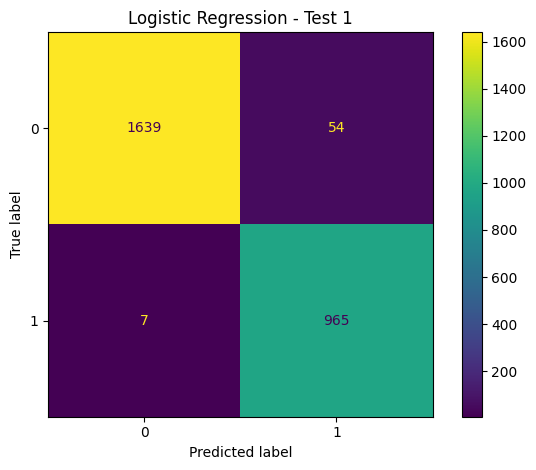

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

ConfusionMatrixDisplay.from_predictions(
    y_test1,
    y_pred_test1
)

plt.title(
    "Logistic Regression - Test 1"
)

plt.tight_layout()

# Create the directory if it does not exist
output_dir = "../results/logistic/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "confusion_matrix_test1.png"),
    dpi=300
)

plt.show()

In [16]:
import os

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Test": "Test 1",
        "Accuracy": accuracy_score(y_test1, y_pred_test1),
        "Precision": precision_score(y_test1, y_pred_test1),
        "Recall": recall_score(y_test1, y_pred_test1),
        "F1": f1_score(y_test1, y_pred_test1),
        "ROC_AUC": roc_auc_score(y_test1, y_prob_test1),
        "Training_Time": training_time
    }
])

# Create the directory if it does not exist
output_dir = "../results/logistic/"
os.makedirs(output_dir, exist_ok=True)

results.to_csv(
    os.path.join(output_dir, "results.csv"),
    index=False
)